In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.decomposition import PCA

import config
from utils.helpers import separate_dataset
from models import SingleTransformer
from train import train_mlm, train_cls
from evaluate import evaluate_mlm, evaluate_cls_cv
from data import load_data, create_dataset
from interpretation.metrics import compute_confusion_matrices, compute_metrics_from_confusion_matrix
from interpretation.visualization import *
from interpretation.similarity import compute_similarity_matrix
from interpretation.latentspace import get_latent_space, analyze_feature_importance

sns.set_style("whitegrid")
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)

In [2]:
fluxes = load_data.load_flux("data/datasets/flux/flux_labelled_11nov.csv", prefix="flux_un",
                                                                 clone_info=True, clone_path="data/datasets/clone/clones.csv", scale=True)
adata_Flux_labelled, adata_Flux_unlabelled, bi_labelled, bi_unlabelled, labels, pcts = fluxes
# with open('objects/atac_labelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_labelled, f)
# with open('objects/atac_unlabelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_unlabelled, f)

print("Flux data loaded.",
        "\nFlux D3 Labelled:", adata_Flux_labelled.shape, list(adata_Flux_labelled.columns)[:5],"...",
        "\nFlux D3 Un-Labelled:", adata_Flux_unlabelled.shape, list(adata_Flux_unlabelled.columns)[:5],"...")

Flux data loaded. 
Flux D3 Labelled: (2008, 168) ['Glucose -> G6P', 'G6P -> G3P', 'G3P -> 3PD', '3PD -> Pyruvate', 'Pyruvate -> Acetyl-Coa'] ... 
Flux D3 Un-Labelled: (100254, 168) ['Glucose -> G6P', 'G6P -> G3P', 'G3P -> 3PD', '3PD -> Pyruvate', 'Pyruvate -> Acetyl-Coa'] ...


In [3]:
mlm_train_loader, mlm_val_loader = create_dataset.get_mlm_loaders(train_data=(adata_Flux_unlabelled, bi_unlabelled), 
                                                                  val_data=(adata_Flux_labelled, bi_labelled), 
                                                                  batch_size=32, 
                                                                  batch_key=None, 
                                                                  data_dtype=torch.float32)

labelled_dataset, pcts, flux_names = create_dataset.get_cls_dataset(data=(adata_Flux_labelled, labels, bi_labelled, pcts),
                                                    batch_key=None,
                                                    label_key=None,
                                                    pct_key=None,
                                                    filter_pcts=10.0,
                                                    data_dtype=torch.float32)
print(len(labelled_dataset))

2008


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_config = {
    "vocab_size": 1,
    "seq_len": next(iter(mlm_train_loader))[0].shape[-1],
    "d_model": 128,
    # "d_batch": 4,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.2
}
model = SingleTransformer(id="Flux", **model_config).to(device)

In [ ]:
mlm_train_loss, mlm_val_loss = train_mlm(model, mlm_train_loader, mlm_val_loader, device,
                                            mse_based=True, epochs=10, lr=5e-4, weight_decay=1e-2, tune_lr=True, 
                                            save_folder="ckp/MLM/", id="Flux", use_multiple_gpu=False)
plot_training_vs_validation_losses(mlm_train_loss, mlm_val_loss, "MLM")

In [5]:
importlib.reload(config)
model.load_state_dict(torch.load(config.MLM_FLUX_CKP))
print(f"Model loaded from checkpoint: {config.MLM_FLUX_CKP}")
val_loss = evaluate_mlm(model, mlm_val_loader, mask_token=-1, mse_based=True, device=device)
print(f"Validation Loss: {val_loss:.4f}")

Model loaded from checkpoint: ckp/MLM/MLM_Flux_ValLoss0.1001.pth


Evaluating MLM:   0%|          | 0/63 [00:00<?, ?it/s]

Validation Loss: 0.1008


In [ ]:
importlib.reload(config)
fold_results = train_cls("Flux", model_config, 
                        labelled_dataset, k_folds=5, batch_size=32, 
                        epochs=15, lr=1e-3, weight_decay=0,
                        use_mlm=True, mlm_path="ckp/MLM/MLM_Flux_ValLoss0.1001.pth", save_path="ckp/CLS", 
                        device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results]):.4f}")

In [ ]:
fold_results_nomlm = train_cls("Flux", model_config, 
                            labelled_dataset, k_folds=5, batch_size=32, 
                            epochs=15, lr=1e-3, weight_decay=0,
                            use_mlm=False, mlm_path=None, save_path="ckp/CLS", 
                            device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results_nomlm]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results_nomlm]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results_nomlm]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f}")

In [5]:
# with open('objects/flux_fold_results_mlm_last_l_conc.pkl', 'wb') as f:
#     pickle.dump(fold_results, f)
# with open('objects/flux_fold_results_nomlm_last_l_conc.pkl', 'wb') as f:
#     pickle.dump(fold_results_nomlm, f)

with open('objects/flux_fold_results_mlm_last_l_conc.pkl', 'rb') as f:
    fold_results = pickle.load(f)
with open('objects/flux_fold_results_nomlm_last_l_conc.pkl', 'rb') as f:
        fold_results_nomlm = pickle.load(f)

In [7]:
# compute mean and std of train_auc and best_val_auc keys in fold_results and fold_results_nomlm
train_auc_mlm = np.mean([fr['train_auc'] for fr in fold_results])
train_auc_nomlm = np.mean([fr['train_auc'] for fr in fold_results_nomlm])
train_auc_mlm_std = np.std([fr['train_auc'] for fr in fold_results])
train_auc_nomlm_std = np.std([fr['train_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm = np.mean([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm = np.mean([fr['best_val_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm_std = np.std([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm_std = np.std([fr['best_val_auc'] for fr in fold_results_nomlm])

print(f"Train AUC: MLM: {train_auc_mlm:.4f} ± {train_auc_mlm_std:.4f}, No-MLM: {train_auc_nomlm:.4f} ± {train_auc_nomlm_std:.4f}")
print(f"Best Val AUC: MLM: {best_val_auc_mlm:.4f} ± {best_val_auc_mlm_std:.4f}, No-MLM: {best_val_auc_nomlm:.4f} ± {best_val_auc_nomlm_std:.4f}")

Train AUC: MLM: 0.8464 ± 0.0116, No-MLM: 0.8217 ± 0.0133
Best Val AUC: MLM: 0.8357 ± 0.0164, No-MLM: 0.8171 ± 0.0205


In [9]:
metrics_mlm = compute_metrics_from_confusion_matrix(cms_mlm[:-1])
metrics_nomlm = compute_metrics_from_confusion_matrix(cms_nomlm[:-1])

avg_mlm = metrics_mlm["average"]
std_mlm = metrics_mlm["std"]
avg_nomlm = metrics_nomlm["average"]
std_nomlm = metrics_nomlm["std"]

print("Flux: MLM")
for k, v in avg_mlm.items():
    print(f"{k}: {v:.4f} ± {std_mlm[k]:.4f}")
print("\nFlux: No-MLM")
for k, v in avg_nomlm.items():
    print(f"{k}: {v:.4f} ± {std_nomlm[k]:.4f}")

Flux: MLM
precision: 0.8586 ± 0.0306
recall: 0.8093 ± 0.0588
f1: 0.8308 ± 0.0157
accuracy: 0.7723 ± 0.0105

Flux: No-MLM
precision: 0.8268 ± 0.0454
recall: 0.8496 ± 0.0472
f1: 0.8355 ± 0.0048
accuracy: 0.7673 ± 0.0175


In [10]:
# print each fold best val auc separate based on mlm and no mlm 5 folds for each)
for i in range(5):
    print(f"Fold {i+1}: MLM: {fold_results[i]['best_val_auc']:.4f}, No-MLM: {fold_results_nomlm[i]['best_val_auc']:.4f}")
print(f"val auc mlm: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}")
print(f"val auc no mlm: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}")
# compute p-value for mlm and no-mlm values for val auc
from scipy.stats import ttest_rel
print("p-value for val auc: ", ttest_rel([fr['best_val_auc'] for fr in fold_results], [fr['best_val_auc'] for fr in fold_results_nomlm]))


Fold 1: MLM: 0.8149, No-MLM: 0.8009
Fold 2: MLM: 0.8376, No-MLM: 0.8087
Fold 3: MLM: 0.8294, No-MLM: 0.8008
Fold 4: MLM: 0.8317, No-MLM: 0.8192
Fold 5: MLM: 0.8648, No-MLM: 0.8557
val auc mlm: 0.8357 ± 0.0164
val auc no mlm: 0.8171 ± 0.0205
p-value for val auc:  TtestResult(statistic=4.415140318716906, pvalue=0.011554390981813491, df=4)


Evaluating Classifier: 0it [00:00, ?it/s]

['(0.8009 | 0.8009)', '(0.8087 | 0.8087)', '(0.8008 | 0.8008)', '(0.8192 | 0.8192)', '(0.8557 | 0.8557)']


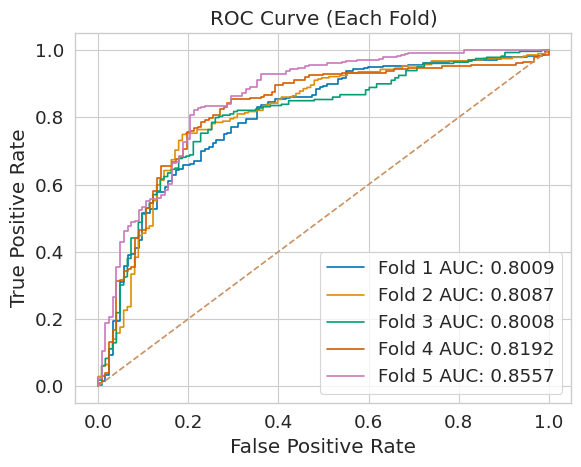

In [11]:
aucs_stored, aucs, val_preds, val_labels = evaluate_cls_cv("Flux", fold_results_nomlm, model_config, labelled_dataset, device)
print([f"({a:.4f} | {b:.4f})" for a,b in zip(aucs_stored, aucs)])
plot_roc_auc_curve(val_preds, val_labels, m_type="Flux", aggregate=False)